In [1]:
import numpy as np
import xarray as xr
import time
import os
import glob
from typing import Tuple, List, Dict, Optional
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import signal, fft
import cmaps
import sys
from pathlib import Path
import psutil
import gc

WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools.utils import dataarray_healpix_to_equatorial_latlon
from wave_tools import calculate_cross_spectrum, quick_cross_spectrum,remove_annual_cycle
from wave_tools.utils import  get_curve

# ============ 内存监控工具 ============
class MemoryMonitor:
    """内存监控类"""
    def __init__(self):
        self.process = psutil.Process()
        
    def get_memory_info(self):
        """获取当前内存使用信息"""
        mem = self.process.memory_info()
        mem_percent = self.process.memory_percent()
        virtual_mem = psutil.virtual_memory()
        
        return {
            'rss_gb': mem.rss / 1024**3,  # 物理内存 (GB)
            'vms_gb': mem.vms / 1024**3,  # 虚拟内存 (GB)
            'percent': mem_percent,        # 进程内存占用百分比
            'available_gb': virtual_mem.available / 1024**3,  # 系统可用内存 (GB)
            'total_gb': virtual_mem.total / 1024**3           # 系统总内存 (GB)
        }
    
    def print_memory_status(self, label=""):
        """打印内存状态"""
        info = self.get_memory_info()
        print(f"\n{'='*60}")
        print(f"💾 内存状态 {f'- {label}' if label else ''}")
        print(f"{'='*60}")
        print(f"  进程物理内存使用: {info['rss_gb']:.2f} GB")
        print(f"  进程虚拟内存使用: {info['vms_gb']:.2f} GB")
        print(f"  进程内存占比: {info['percent']:.1f}%")
        print(f"  系统可用内存: {info['available_gb']:.2f} GB / {info['total_gb']:.2f} GB")
        print(f"{'='*60}\n")
        
        # 如果可用内存不足10GB，发出警告
        if info['available_gb'] < 10:
            print("⚠️  警告: 系统可用内存不足10GB!")
        
        return info

# 创建全局内存监控器
mem_monitor = MemoryMonitor()

def dataarray_to_equatorial_latlon_grid(
    dataarray: xr.DataArray, grid_type: str, grid_dict: Optional[dict]
) -> xr.DataArray:
    """转换数据到赤道经纬度网格"""
    if grid_type == "latlon":
        return dataarray
    elif grid_type == "healpix":
        if grid_dict is None:
            raise ValueError("No grid_dict provided for healpix conversion.")
        return dataarray_healpix_to_equatorial_latlon(dataarray, **grid_dict)
    else:
        raise ValueError("Grid type not found.")

FIG_SAVE_DIR = "../figures/cross_spectrum_wdhdz/"

# 创建必要的目录
for d in [FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

# 初始内存状态
mem_monitor.print_memory_status("初始化")



💾 内存状态 - 初始化
  进程物理内存使用: 1.20 GB
  进程虚拟内存使用: 19.46 GB
  进程内存占比: 0.2%
  系统可用内存: 143.77 GB / 501.87 GB



{'rss_gb': 1.20166015625,
 'vms_gb': 19.45722198486328,
 'percent': 0.23943561821447665,
 'available_gb': 143.77145767211914,
 'total_gb': 501.8719291687012}

In [2]:
# ============ 加载降水数据 ============

def load_precipitation_data(experiment='cntl', data_dir='/work/mh1498/m301257/data_origin', 
                           chunks={'time': 500}):
    """
    加载降水数据 (使用 chunking 避免内存溢出)
    
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    chunks : dict
        数据分块参数，默认按时间维度每100个时间步分一块
    
    Returns:
    --------
    xr.DataArray
        降水数据 (lazy loading)
    """
    # 构建文件路径
    file_path = os.path.join(data_dir, f'pr_{experiment}_2deg_interp.nc')
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到实验 {experiment} 的降水数据文件: {file_path}")
    
    print(f"📂 加载数据: {file_path}")
    
    # 使用 chunks 参数实现 lazy loading
    try:
        pr = xr.open_dataarray(file_path, engine='netcdf4', chunks=chunks)
    except:
        try:
            pr = xr.open_dataarray(file_path, engine='h5netcdf', chunks=chunks)
        except:
            pr = xr.open_dataarray(file_path, chunks=chunks)
    
    print(f"✅ 数据加载成功 (lazy loading)")
    print(f"   形状: {pr.shape}")
    print(f"   维度: {pr.dims}")
    print(f"   数据块: {pr.chunks}")
    if hasattr(pr, 'time'):
        print(f"   时间范围: {pr.time.values[0]} to {pr.time.values[-1]}")
    
    # 估算数据大小
    data_size_gb = pr.nbytes / 1024**3
    print(f"   估算数据大小: {data_size_gb:.2f} GB")
    
    return pr


def load_all_precipitation_data(chunks={'time': 5000}):
    """
    加载所有实验的降水数据 (使用 lazy loading)
    
    Parameters:
    -----------
    chunks : dict
        数据分块参数
    
    Returns:
    --------
    dict
        包含所有实验降水数据的字典
    """
    print("\n" + "="*60)
    print("加载所有降水数据")
    print("="*60)
    
    mem_monitor.print_memory_status("加载降水数据前")
    
    experiments = ['cntl', 'p4k', '4co2']
    pr_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            pr = load_precipitation_data(exp, chunks=chunks)
            pr_data[exp] = pr
        except Exception as e:
            print(f"❌ 错误: {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(pr_data)} 个实验的数据")
    print(f"{'='*60}")
    
    mem_monitor.print_memory_status("加载降水数据后")
    
    return pr_data
# 加载所有实验的降水数据
pr_data = load_all_precipitation_data()


加载所有降水数据

💾 内存状态 - 加载降水数据前
  进程物理内存使用: 1.20 GB
  进程虚拟内存使用: 19.46 GB
  进程内存占比: 0.2%
  系统可用内存: 143.76 GB / 501.87 GB


加载 CNTL...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_cntl_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((5000, 114), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

加载 P4K...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_p4k_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((5000, 114), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

加载 4CO2...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_4co2_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((5000, 114), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

✅ 成功加载 3 个实验的数据

💾 内存状态 - 加载降水数据后
  进程物理内

In [3]:
ds_msevdv = xr.open_dataset("../processed_data/Cal_vertical_mse_advection/" + 'mse_vertical_advection_integrated_rho_half.nc', chunks={'time': 5000})
ds_msevdv

<xarray.Dataset> Size: 331MB
Dimensions:            (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time               (time) datetime64[ns] 41kB 1980-01-01 ... 1993-12-31
  * lat                (lat) float64 120B -14.0 -12.0 -10.0 ... 10.0 12.0 14.0
  * lon                (lon) float64 1kB 0.0 2.0 4.0 6.0 ... 354.0 356.0 358.0
Data variables:
    mse_vadv_int_cntl  (time, lat, lon) float64 110MB dask.array<chunksize=(5000, 15, 180), meta=np.ndarray>
    mse_vadv_int_p4k   (time, lat, lon) float64 110MB dask.array<chunksize=(5000, 15, 180), meta=np.ndarray>
    mse_vadv_int_4co2  (time, lat, lon) float64 110MB dask.array<chunksize=(5000, 15, 180), meta=np.ndarray>

In [4]:
vdv_data = {'cntl': ds_msevdv['mse_vadv_int_cntl'],
            'p4k': ds_msevdv['mse_vadv_int_p4k'],
            '4co2': ds_msevdv['mse_vadv_int_4co2']}
vdv_data

{'cntl': <xarray.DataArray 'mse_vadv_int_cntl' (time: 5114, lat: 15, lon: 180)> Size: 110MB
 dask.array<open_dataset-mse_vadv_int_cntl, shape=(5114, 15, 180), dtype=float64, chunksize=(5000, 15, 180), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
 Attributes:
     long_name:    Vertically integrated MSE vertical advection (CNTL)
     units:        W m-2
     description:  Integral of wa * dh/dz over height,
 'p4k': <xarray.DataArray 'mse_vadv_int_p4k' (time: 5114, lat: 15, lon: 180)> Size: 110MB
 dask.array<open_dataset-mse_vadv_int_p4k, shape=(5114, 15, 180), dtype=float64, chunksize=(5000, 15, 180), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lat      (lat) float64 120B -14.0 -12.0

In [5]:
# ============ 网格对齐函数 ============

def align_grids(pr_data, div_data):
    """
    确保降水和散度数据在相同的网格上
    
    Parameters:
    -----------
    pr_data : xr.DataArray
        降水数据
    div_data : xr.DataArray
        散度数据
    
    Returns:
    --------
    tuple : (pr_aligned, div_aligned)
        对齐后的降水和散度数据
    """
    print(f"  原始形状: pr={pr_data.shape}, div={div_data.shape}")
    
    # 检查经度维度
    pr_lon = pr_data.lon.values
    div_lon = div_data.lon.values
    
    if len(pr_lon) != len(div_lon):
        print(f"  ⚠️ 经度维度不匹配: pr有{len(pr_lon)}个点, div有{len(div_lon)}个点")
        print(f"  🔧 将散度数据插值到降水网格...")
        
        # 将散度数据插值到降水的网格，使用最近邻以避免边界NaN
        div_aligned = div_data.interp(lon=pr_data.lon, lat=pr_data.lat, 
                                      method='linear', 
                                      kwargs={'fill_value': 'extrapolate'})
        
        # 检查并处理NaN值
        nan_count_before = np.isnan(div_aligned.values).sum()
        if nan_count_before > 0:
            print(f"  ⚠️ 插值后发现 {nan_count_before} 个NaN值，进行填充...")
            # 使用最近邻填充剩余的NaN
            div_aligned = div_aligned.fillna(div_data.interp(lon=pr_data.lon, lat=pr_data.lat, 
                                                              method='nearest'))
            nan_count_after = np.isnan(div_aligned.values).sum()
            print(f"  ✓ 填充后剩余 {nan_count_after} 个NaN值")
            
            # 如果还有NaN，用0填充（极端情况）
            if nan_count_after > 0:
                div_aligned = div_aligned.fillna(0)
                print(f"  ✓ 剩余NaN值已用0填充")
    else:
        div_aligned = div_data
    
    print(f"  对齐后形状: pr={pr_data.shape}, div={div_aligned.shape}")
    
    return pr_data, div_aligned

In [6]:
def _ocean():
    fraction = xr.open_dataarray(r'../processed_data/land_mask_2deg.nc')
    return fraction == 0
ocean_mask = _ocean()

In [7]:
# crossspectrum_results = {}
# for exp_name in ['cntl', 'p4k', '4co2']:
#     print(f"\n{'='*60}")
#     print(f"  处理 {exp_name.upper()}...")
#     print(f"{'='*60}")
    
#     # 获取降水和散度数据
#     pr_raw = pr_data[exp_name].where(ocean_mask, drop=True)
#     vdv_raw = vdv_data[exp_name].where(ocean_mask, drop=True)
   
#     # 计算异常值（去除年循环）
#     pr_ano = pr_raw.groupby('time.dayofyear') - pr_raw.groupby('time.dayofyear').mean()
#     vdv_ano = vdv_raw.groupby('time.dayofyear') - vdv_raw.groupby('time.dayofyear').mean()

#     print(f"\n  步骤1: 计算异常值后的数据统计")
#     print(f"    pr_ano: NaN={np.isnan(pr_ano.values).sum()}, Inf={np.isinf(pr_ano.values).sum()}")
#     print(f"    vdv_ano: NaN={np.isnan(vdv_ano.values).sum()}, Inf={np.isinf(vdv_ano.values).sum()}")
    
#     # 应用海洋掩膜（使用 * 运算符代替 where 避免对齐问题）
#     # 将掩膜转换为0和1，然后与数据相乘
#     ocean_mask_binary = ocean_mask.astype(float)
#     pr_ano = pr_ano * ocean_mask_binary
#     vdv_ano = vdv_ano * ocean_mask_binary
    
#     print(f"\n  步骤2: 应用海洋掩膜后的数据统计")
#     print(f"    pr_ano: NaN={np.isnan(pr_ano.values).sum()}, Inf={np.isinf(pr_ano.values).sum()}")
#     print(f"    vdv_ano: NaN={np.isnan(vdv_ano.values).sum()}, Inf={np.isinf(vdv_ano.values).sum()}")
    
#     # ========== 关键步骤：处理NaN和Inf值 ==========
#     # 方法1：用0填充NaN和Inf（适用于海洋掩膜已经将陆地设为NaN的情况）
#     # NaN值通常来自陆地区域或数据缺失，填充为0不会影响交叉谱分析
#     print(f"\n  步骤3: 清理NaN和Inf值...")
    
#     # 先处理Inf值（替换为NaN）
#     pr_ano = xr.where(np.isinf(pr_ano), np.nan, pr_ano)
#     vdv_ano = xr.where(np.isinf(vdv_ano), np.nan, vdv_ano)
    
#     # 然后用0填充所有NaN值
#     pr_ano = pr_ano.fillna(0)
#     vdv_ano = vdv_ano.fillna(0)
#     pr_ano = remove_annual_cycle(pr_ano)
#     vdv_ano = remove_annual_cycle(vdv_ano)
#     print(f"    清理后统计:")
#     print(f"    pr_ano: NaN={np.isnan(pr_ano.values).sum()}, Inf={np.isinf(pr_ano.values).sum()}")
#     print(f"    vdv_ano: NaN={np.isnan(vdv_ano.values).sum()}, Inf={np.isinf(vdv_ano.values).sum()}")
#     print(f"    pr_ano range: [{np.min(pr_ano.values):.6e}, {np.max(pr_ano.values):.6e}]")
#     print(f"    vdv_ano range: [{np.min(vdv_ano.values):.6e}, {np.max(vdv_ano.values):.6e}]")
    
#     # 计算交叉谱 - 使用wave_tools的函数                                                                                                                                                          
#     result = calculate_cross_spectrum(
#         pr_ano, vdv_ano, 
#         segLen=96, 
#         segOverLap=-65,
#         symmetry='symm',
#         return_xarray=True
#     )
    
#     # 提取结果（现在result['STC']已经是xarray DataArray）
#     if result is None:
#         print(f"    ✗ 交叉谱计算失败，返回None")
#         continue
        
#     stc_da = result['STC']  # 已经是xarray DataArray
#     zonalwnum = result['wave']
#     freq = result['freq']
#     stc = stc_da.values  # 如果需要numpy数组
    
#     print(f"    ✓ 交叉谱计算成功！")
#     print(f"      STC shape: {stc_da.shape}")
#     print(f"      波数范围: {zonalwnum.min():.2f} ~ {zonalwnum.max():.2f}")
#     print(f"      频率范围: {freq.min():.4f} ~ {freq.max():.4f}")
    
#     # 存储结果 - stc_da已经是正确格式，不需要再次转换
#     crossspectrum_results[exp_name] = {
#         'STC': stc_da,  # 直接使用返回的DataArray
#         'freq': freq,
#         'wave': zonalwnum,
#         'nseg': result['nseg'],
#         'dof': result['dof'],
#         'p': result['p'],
#         'prob_coh2': result['prob_coh2']
#     }

# print("\n" + "="*60)
# print("✅ 所有实验的交叉谱计算完成！")
# print("="*60)

In [8]:
import dask
from dask.diagnostics import ProgressBar
import dask.array as da

# 配置 Dask（根据你的计算资源调整）
dask.config.set({
    'array.slicing.split_large_chunks': True,
    'array.chunk-size': '128MB',  # 每个 chunk 的目标大小
})

# 如果有多核，可以启用多线程调度器
dask.config.set(scheduler='threads')  # 或 'processes'

print("Dask 配置完成！")
print(f"  调度器: {dask.config.get('scheduler', default='default')}")
print(f"  Chunk 大小: {dask.config.get('array.chunk-size')}")

Dask 配置完成！
  调度器: threads
  Chunk 大小: 128MB


In [9]:
def preprocess_data_with_dask(pr_raw, vdv_raw, ocean_mask):
    """
    使用 Dask 优化数据预处理流程
    
    Parameters:
    -----------
    pr_raw : xr.DataArray (with dask chunks)
        原始降水数据
    vdv_raw : xr.DataArray (with dask chunks)
        原始散度数据
    ocean_mask : xr.DataArray
        海洋掩膜
        
    Returns:
    --------
    pr_ano, vdv_ano : xr.DataArray
        预处理后的异常值数据（仍然是 dask 数组，延迟计算）
    """
    
    # 步骤1：计算异常值（去除年循环）- Dask 会自动优化这个 groupby 操作
    print("  📊 步骤1: 计算异常值（延迟计算）...")
    pr_ano = pr_raw.groupby('time.dayofyear') - pr_raw.groupby('time.dayofyear').mean()
    vdv_ano = vdv_raw.groupby('time.dayofyear') - vdv_raw.groupby('time.dayofyear').mean()
    
    # 步骤2：应用海洋掩膜
    print("  🌊 步骤2: 应用海洋掩膜（延迟计算）...")
    ocean_mask_binary = ocean_mask.astype(float)
    pr_ano = pr_ano * ocean_mask_binary
    vdv_ano = vdv_ano * ocean_mask_binary
    
    # 步骤3：处理 NaN 和 Inf 值（延迟计算）
    print("  🧹 步骤3: 清理 NaN 和 Inf 值（延迟计算）...")
    
    # 使用 xr.where 处理 Inf（Dask 兼容）
    pr_ano = xr.where(np.isinf(pr_ano), np.nan, pr_ano)
    vdv_ano = xr.where(np.isinf(vdv_ano), np.nan, vdv_ano)
    
    # 填充 NaN（Dask 兼容）
    pr_ano = pr_ano.fillna(0)
    vdv_ano = vdv_ano.fillna(0)
    
    # 再次去除年循环（使用 wave_tools 函数）
    print("  🔄 步骤4: 再次去除年循环（延迟计算）...")
    pr_ano = remove_annual_cycle(pr_ano)
    vdv_ano = remove_annual_cycle(vdv_ano)
    
    print("  ✅ 预处理完成（尚未执行计算）")
    print(f"     pr_ano chunks: {pr_ano.chunks}")
    print(f"     vdv_ano chunks: {vdv_ano.chunks}")
    
    return pr_ano, vdv_ano


print("✅ Dask 优化函数定义完成！")

✅ Dask 优化函数定义完成！


In [10]:
# ============ 使用 Dask 加速的交叉谱计算 ============

crossspectrum_results_dask = {}

for exp_name in ['cntl', 'p4k', '4co2']:
    print(f"\n{'='*60}")
    print(f"  🚀 处理 {exp_name.upper()}（Dask 优化版）...")
    print(f"{'='*60}")
    
    mem_monitor.print_memory_status(f"开始处理 {exp_name}")
    
    # 获取降水和散度数据（保持 chunked 状态）
    pr_raw = pr_data[exp_name].where(ocean_mask, drop=True)
    vdv_raw = vdv_data[exp_name].where(ocean_mask, drop=True)
    
    print(f"  📦 原始数据 chunks:")
    print(f"     pr_raw: {pr_raw.chunks if hasattr(pr_raw, 'chunks') else 'No chunks'}")
    print(f"     vdv_raw: {vdv_raw.chunks if hasattr(vdv_raw, 'chunks') else 'No chunks'}")
    
    # ========== 使用 Dask 优化的预处理 ==========
    start_time = time.time()
    
    # 延迟计算预处理步骤
    pr_ano, vdv_ano = preprocess_data_with_dask(pr_raw, vdv_raw, ocean_mask)
    
    preprocess_setup_time = time.time() - start_time
    print(f"\n  ⏱️  预处理设置时间: {preprocess_setup_time:.2f}s（延迟计算）")
    
    # ========== 执行计算（使用进度条） ==========
    print(f"\n  🔥 开始执行计算...")
    compute_start = time.time()
    
    with ProgressBar():
        # 方式1：一次性计算所有预处理（内存占用更高，但速度更快）
        print("     方式: 一次性计算所有预处理")
        pr_ano_computed, vdv_ano_computed = dask.compute(pr_ano, vdv_ano)
        
        # 方式2：分步计算（内存占用更低，但速度稍慢）
        # print("     方式: 分步计算")
        # pr_ano_computed = pr_ano.compute()
        # vdv_ano_computed = vdv_ano.compute()
    
    compute_time = time.time() - compute_start
    print(f"  ⏱️  计算执行时间: {compute_time:.2f}s")
    
    # 验证数据
    print(f"\n  ✅ 数据统计:")
    print(f"     pr_ano: NaN={np.isnan(pr_ano_computed.values).sum()}, "
          f"Inf={np.isinf(pr_ano_computed.values).sum()}")
    print(f"     vdv_ano: NaN={np.isnan(vdv_ano_computed.values).sum()}, "
          f"Inf={np.isinf(vdv_ano_computed.values).sum()}")
    print(f"     pr_ano range: [{np.min(pr_ano_computed.values):.6e}, "
          f"{np.max(pr_ano_computed.values):.6e}]")
    print(f"     vdv_ano range: [{np.min(vdv_ano_computed.values):.6e}, "
          f"{np.max(vdv_ano_computed.values):.6e}]")
    
    mem_monitor.print_memory_status(f"预处理完成 {exp_name}")
    
    # ========== 计算交叉谱（这一步无法用 Dask 加速） ==========
    print(f"\n  📊 计算交叉谱...")
    
    
    result = calculate_cross_spectrum(
        pr_ano_computed, vdv_ano_computed, 
        segLen=96, 
        segOverLap=-65,
        symmetry='symm',
        return_xarray=True
    )
    
    
    
    # 提取结果
    if result is None:
        print(f"    ✗ 交叉谱计算失败，返回None")
        continue
        
    stc_da = result['STC']
    zonalwnum = result['wave']
    freq = result['freq']
    
    print(f"    ✓ 交叉谱计算成功！")
    print(f"      STC shape: {stc_da.shape}")
    print(f"      波数范围: {zonalwnum.min():.2f} ~ {zonalwnum.max():.2f}")
    print(f"      频率范围: {freq.min():.4f} ~ {freq.max():.4f}")
    
    # 存储结果
    crossspectrum_results_dask[exp_name] = {
        'STC': stc_da,
        'freq': freq,
        'wave': zonalwnum,
        'nseg': result['nseg'],
        'dof': result['dof'],
        'p': result['p'],
        'prob_coh2': result['prob_coh2']
    }
    
    total_time = time.time() - start_time
    print(f"\n  ⏱️  总耗时: {total_time:.2f}s")
    print(f"     预处理: {compute_time:.2f}s ({compute_time/total_time*100:.1f}%)")
    
    
    mem_monitor.print_memory_status(f"完成 {exp_name}")
    
    # 清理内存
    del pr_ano, vdv_ano, pr_ano_computed, vdv_ano_computed
    gc.collect()

print("\n" + "="*60)
print("✅ 所有实验的交叉谱计算完成（Dask 优化版）！")
print("="*60)


  🚀 处理 CNTL（Dask 优化版）...

💾 内存状态 - 开始处理 cntl
  进程物理内存使用: 1.25 GB
  进程虚拟内存使用: 19.62 GB
  进程内存占比: 0.2%
  系统可用内存: 142.95 GB / 501.87 GB

  📦 原始数据 chunks:
     pr_raw: ((5000, 114), (15,), (167,))
     vdv_raw: ((5000, 114), (15,), (167,))
  📊 步骤1: 计算异常值（延迟计算）...
  🌊 步骤2: 应用海洋掩膜（延迟计算）...
  🧹 步骤3: 清理 NaN 和 Inf 值（延迟计算）...
  🔄 步骤4: 再次去除年循环（延迟计算）...
  ✅ 预处理完成（尚未执行计算）
     pr_ano chunks: None
     vdv_ano chunks: None

  ⏱️  预处理设置时间: 5.16s（延迟计算）

  🔥 开始执行计算...
     方式: 一次性计算所有预处理
  ⏱️  计算执行时间: 0.00s

  ✅ 数据统计:
     pr_ano: NaN=0, Inf=0
     vdv_ano: NaN=0, Inf=0
     pr_ano range: [-8.659267e-04, 6.449182e-03]
     vdv_ano range: [-3.738006e+03, 4.853984e+03]

💾 内存状态 - 预处理完成 cntl
  进程物理内存使用: 2.20 GB
  进程虚拟内存使用: 23.20 GB
  进程内存占比: 0.4%
  系统可用内存: 142.43 GB / 501.87 GB


  📊 计算交叉谱...
    ✓ 交叉谱计算成功！
      STC shape: (8, 49, 167)
      波数范围: -83.00 ~ 83.00
      频率范围: 0.0000 ~ 0.5000

  ⏱️  总耗时: 22.98s
     预处理: 0.00s (0.0%)

💾 内存状态 - 完成 cntl
  进程物理内存使用: 2.21 GB
  进程虚拟内存使用: 23.20 GB
  进程内存占比: 0.4%


In [11]:
outpath = "/work/mh1498/m301257/Plot_data/crossspectrum_pr_vdv_dask.npz"

np.savez(outpath, **crossspectrum_results_dask)

print(f"✅ 交叉谱结果已保存到 {outpath}")


✅ 交叉谱结果已保存到 /work/mh1498/m301257/Plot_data/crossspectrum_pr_vdv_dask.npz


In [12]:
# np.load(outpath, allow_pickle=True)

  CNTL: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 2617/8183
     有效的矢量数: 645
  P4K: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 3888/8183
     有效的矢量数: 974
  4CO2: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 2321/8183
     有效的矢量数: 565

✅ 图片已保存: ../figures/cross_spectrum_wdhdz/cross_spectrum_pr_vdv_symm_99%.png

✅ 图片已保存: ../figures/cross_spectrum_wdhdz/cross_spectrum_pr_vdv_symm_99%.png


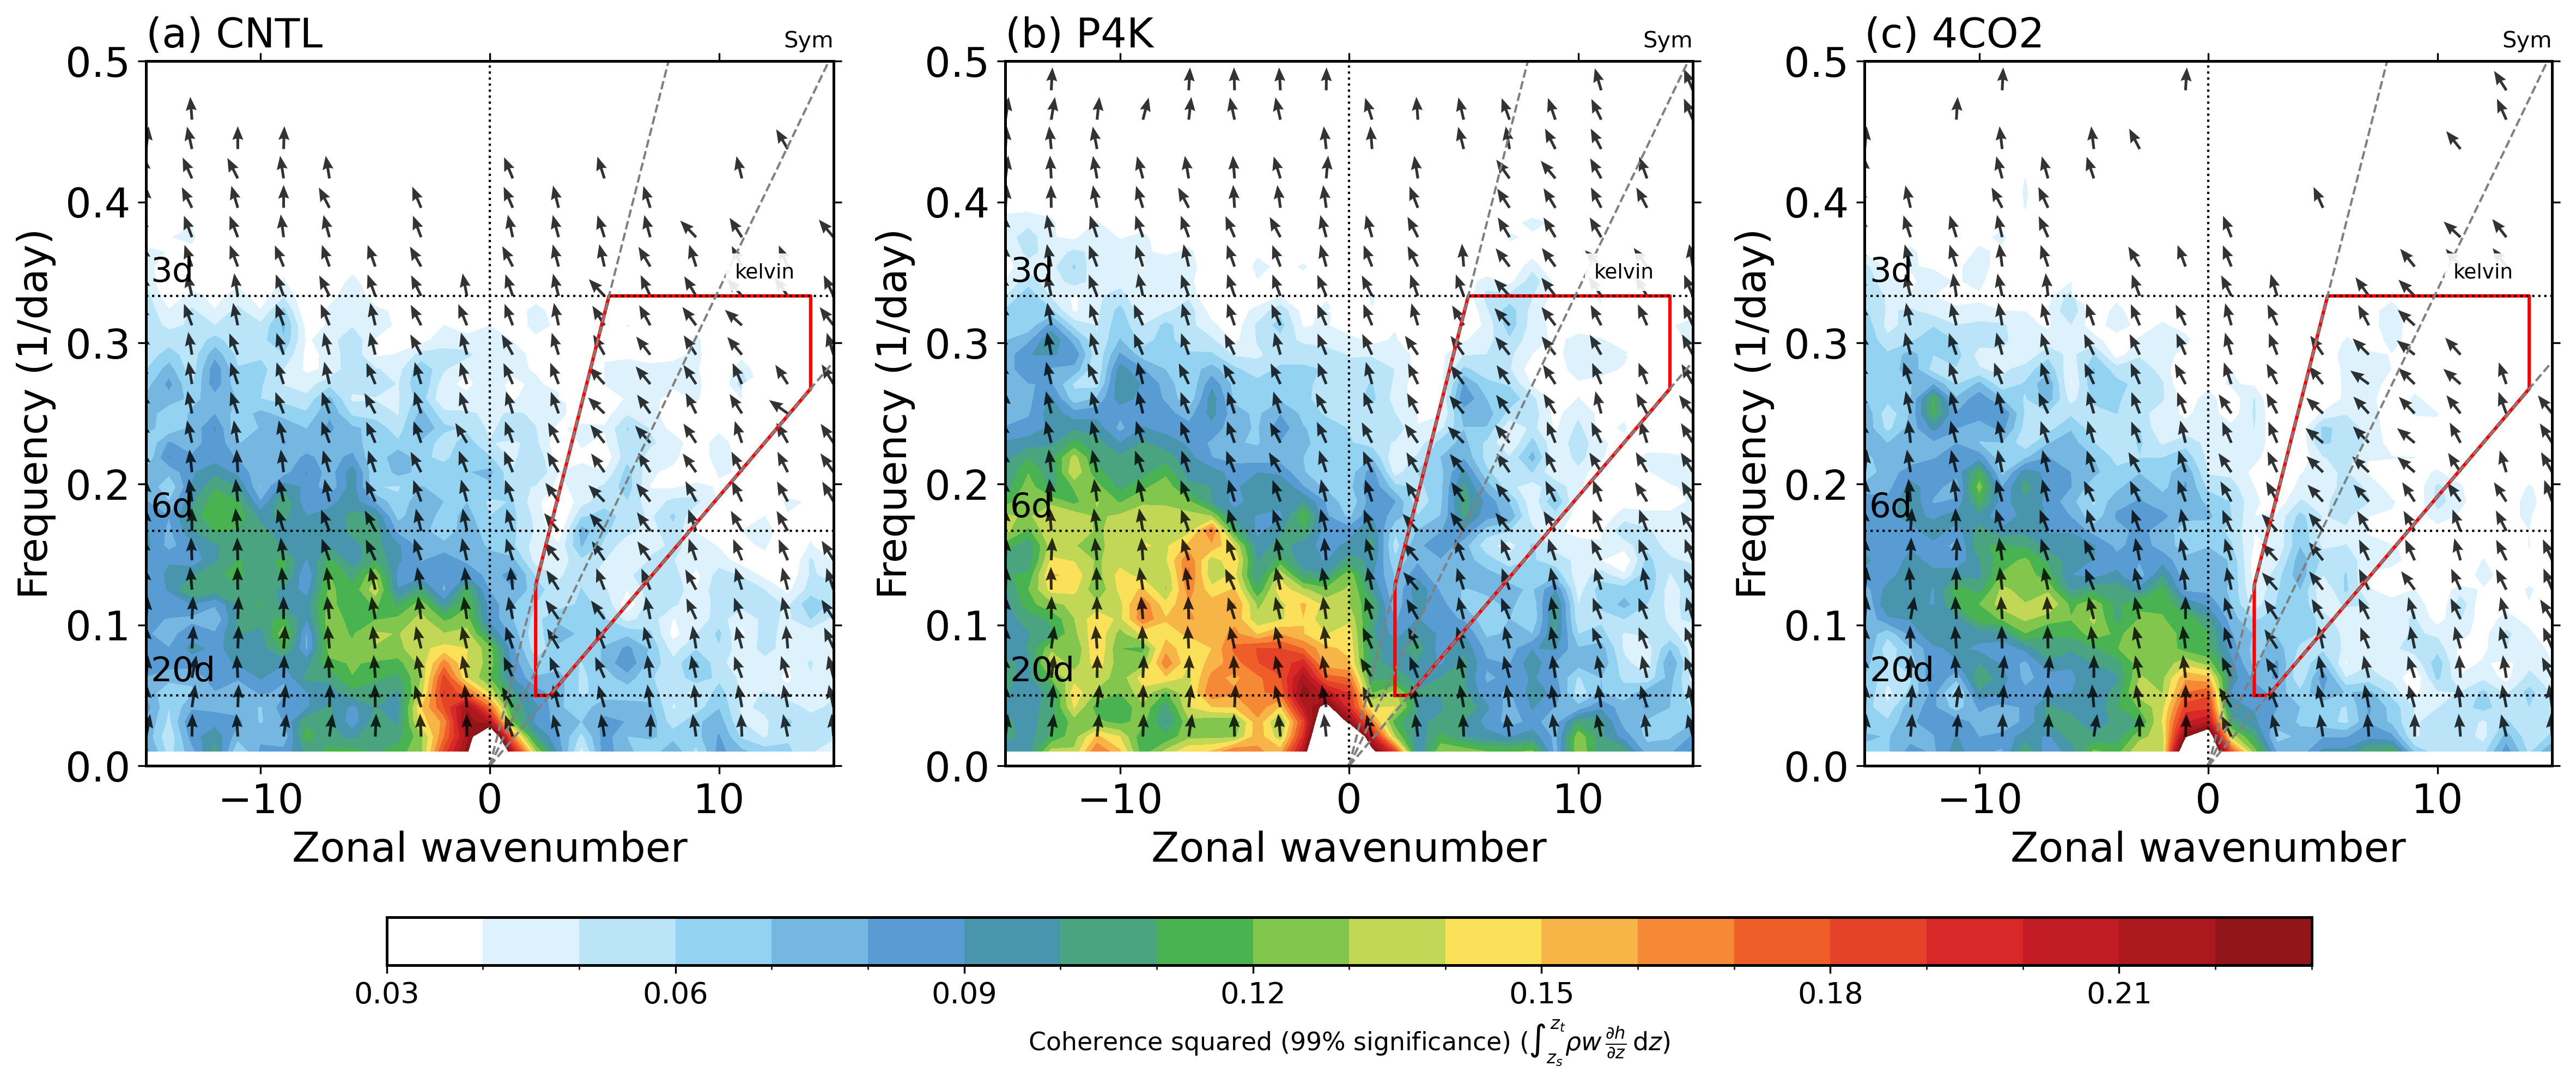

In [18]:
s2d = 86400
re = 6371 * 1000

# 创建3个子图
fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
plt.rcParams.update({'font.size': 10})

exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']

for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
    plt.sca(ax)

    # 获取当前实验的结果
    stc = crossspectrum_results_dask[exp_name]['STC']
    zonalwnum = crossspectrum_results_dask[exp_name]['wave']
    freq = crossspectrum_results_dask[exp_name]['freq']
    
    # 🔑 关键：获取99%置信水平的临界值
    coh2_99_threshold_array = crossspectrum_results_dask[exp_name]['prob_coh2']
    
    # 如果是数组，取最大值（最保守的检验）
    if isinstance(coh2_99_threshold_array, np.ndarray) and coh2_99_threshold_array.size > 1:
        coh2_99_threshold = float(coh2_99_threshold_array.max())
    elif hasattr(coh2_99_threshold_array, 'item'):
        coh2_99_threshold = float(coh2_99_threshold_array.item())
    else:
        coh2_99_threshold = float(coh2_99_threshold_array)
    
    print(f"  {exp_name.upper()}: 99%显著性阈值 = {coh2_99_threshold:.6f}")
    
    # 获取coherence squared数据
    coh2_data = stc.sel(component='COH2')
    
    # 检查有多少点通过显著性检验
    n_significant = int((coh2_data >= coh2_99_threshold).sum())
    print(f"     通过99%显著性检验的点数: {n_significant}/{coh2_data.size}")
    
    # 🔑 使用99%置信水平阈值进行掩蔽
    coh2_data_masked = coh2_data.where(coh2_data >= coh2_99_threshold)

    # 绘制coherence squared的等高线图（只显示通过检验的）
    contourf = coh2_data_masked.plot.contourf(
        ax=ax,
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=np.linspace(0.03, 0.23, 21),
        add_colorbar=False,
        add_labels=False,
        extend='neither'
    )

    # 准备矢量场数据
    skip = 2
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc.sel(component='V1').values[::skip, ::skip]
    v_sub = stc.sel(component='V2').values[::skip, ::skip]
    coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]

    # 🔑 使用99%置信水平阈值掩蔽矢量场
    mask = coh2_sub < coh2_99_threshold
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)
    
    # 检查有效矢量数
    n_valid_vectors = np.sum(~np.isnan(u_masked))
    print(f"     有效的矢量数: {n_valid_vectors}")

    # 添加矢量场
    if n_valid_vectors > 0:
        q = ax.quiver(
            wave_sub, freq_sub,
            u_masked, v_masked,
            scale=30, headwidth=4, headlength=5, 
            width=0.004, alpha=0.8
        )

    # 设置标题
    ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18, loc='left')
    ax.set_title(f'Sym', fontsize=10, loc='right')

    # 设置坐标轴
    ax.set_ylabel('Frequency (1/day)', fontsize=18)
    ax.set_xlabel('Zonal wavenumber', fontsize=18)
    ax.set_xlim(-15, 15)
    ax.set_ylim(0, 0.5)
    kw_x, kw_y = get_curve()
    # 绘制CCKW波段
    ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')

    # 添加参考线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

    # 周期线
    for dd in range(len(d)):
        ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
        ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')

    # Kelvin波色散关系
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

    # 添加"kelvin"标签
    ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
    ax.tick_params(labelsize=18, which='both', top=True, right=True)

# 添加颜色条
cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                    pad=0.15, aspect=40, shrink=0.8)
cbar.set_label(r'Coherence squared (99% significance) ($\int_{z_s}^{z_t} \rho w \, \frac{\partial h}{\partial z} \, \mathrm{d}z$)', fontsize=11)

fig.savefig(FIG_SAVE_DIR + 'cross_spectrum_pr_vdv_symm_99%.png', bbox_inches='tight')
print(f"\n✅ 图片已保存: {FIG_SAVE_DIR}cross_spectrum_pr_vdv_symm_99%.png")

第一行：原始实验数据（99%显著性检验）

  CNTL: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 2617/8183
     有效的矢量数: 645

  P4K: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 3888/8183
     有效的矢量数: 974

  4CO2: 99%显著性阈值 = 0.020437
     通过99%显著性检验的点数: 2321/8183
     有效的矢量数: 565

第二行：差异图（不应用显著性检验，显示所有差异）

  P4K - CNTL
     显著差异的矢量数（|diff|>0.02）: 217

  4CO2 - CNTL
     显著差异的矢量数（|diff|>0.02）: 49

✅ 图片已保存: ../figures/cross_spectrum_wdhdz/cross_spectrum_pr_vdv_symm_kelvin_with_diff_99%.png

✅ 图片已保存: ../figures/cross_spectrum_wdhdz/cross_spectrum_pr_vdv_symm_kelvin_with_diff_99%.png


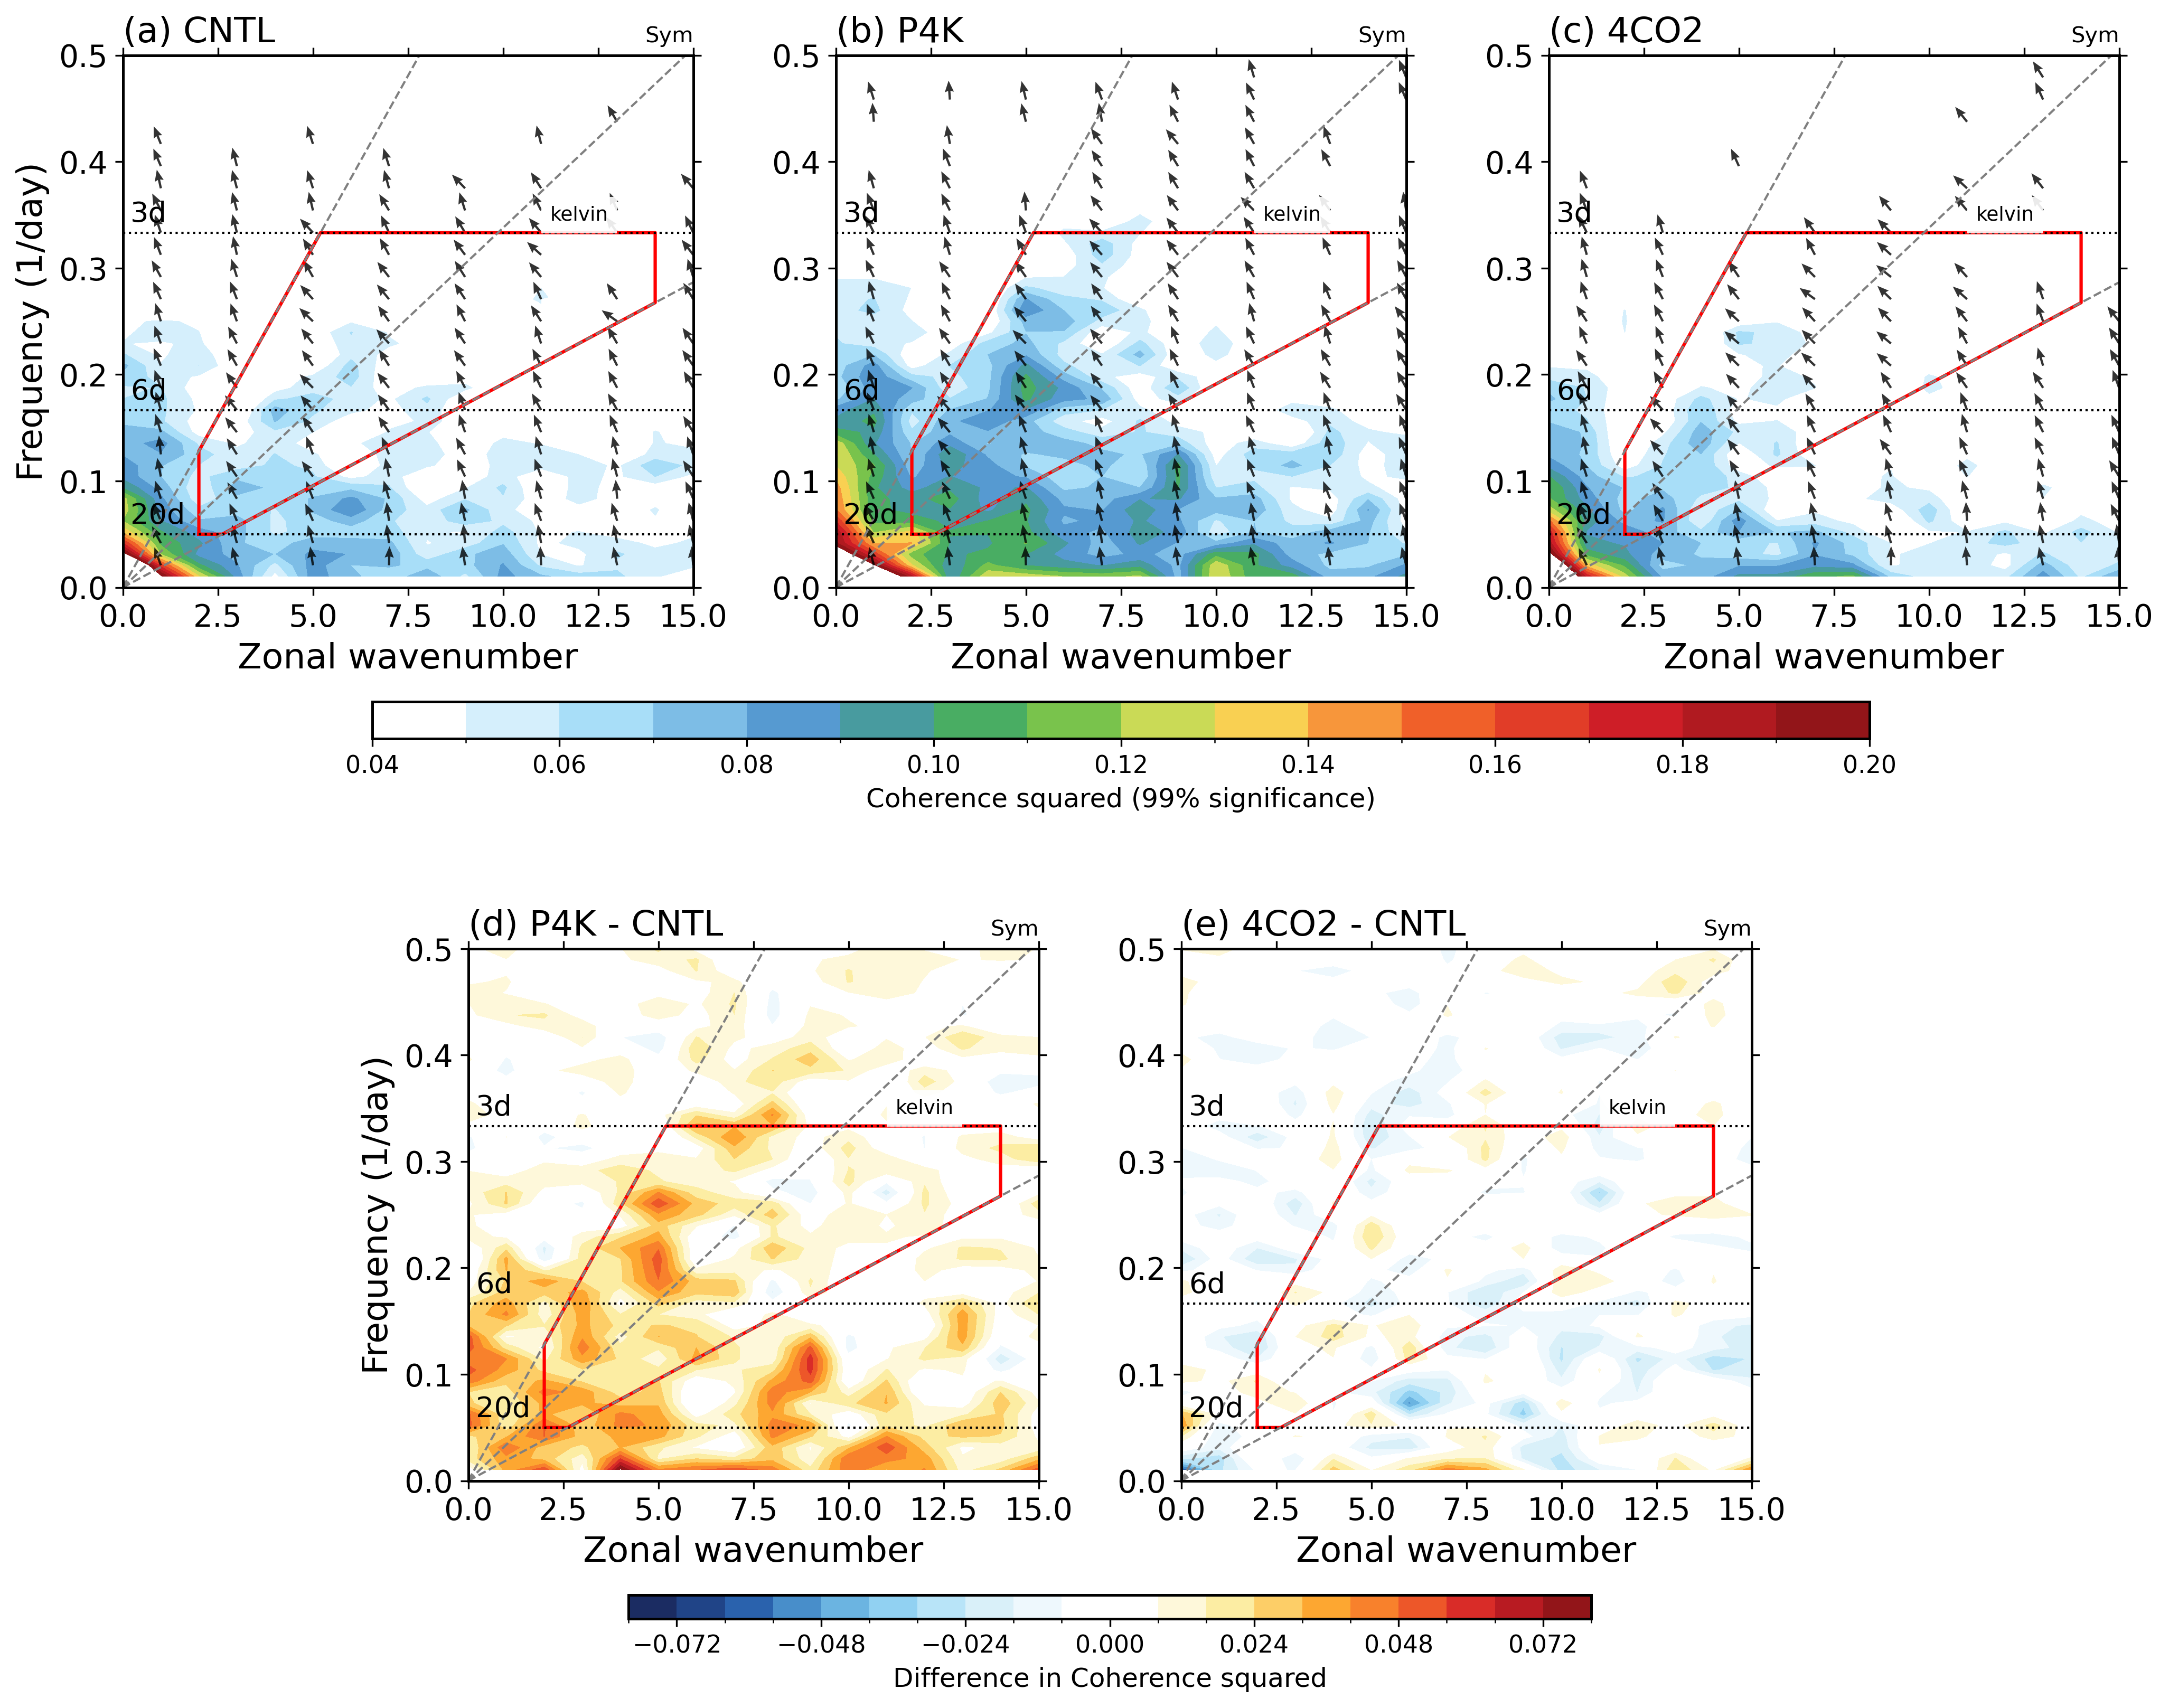

In [19]:
s2d = 86400
re = 6371 * 1000

# 创建图形：2行布局
from matplotlib.gridspec import GridSpec
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.linewidth': 1.2
})

fig = plt.figure(figsize=(14, 12), dpi=300)

# 使用GridSpec创建第一行的子图
gs = GridSpec(
    1, 3, figure=fig,
    left=0.08, right=0.98, top=0.95, bottom=0.55,
    wspace=0.25
)

# 第一行：3个子图
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
axes_row1 = [ax1, ax2, ax3]

# 获取第一行第一个子图的位置信息，用于确定子图的宽度和高度
pos1 = ax1.get_position()
subplot_width = pos1.width
subplot_height = pos1.height

# 计算第一行三个子图之间的间距
pos2 = ax2.get_position()
gap = pos2.x0 - pos1.x1

# 第二行：使用add_axes手动添加2个子图，使其大小与第一行一致
# 计算第二行的起始位置（居中）
row2_y = 0.08  # 第二行的底部位置
total_width_row2 = 2 * subplot_width + gap  # 两个子图加一个间距的总宽度
start_x_row2 = (1.05 - total_width_row2) / 2  # 居中起始位置

# 创建第二行的两个子图
ax_diff1 = fig.add_axes([start_x_row2, row2_y, subplot_width, subplot_height])
ax_diff2 = fig.add_axes([start_x_row2 + subplot_width + gap, row2_y, subplot_width, subplot_height])
axes_row2 = [ax_diff1, ax_diff2]


exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']
diff_titles = ['P4K - CNTL', '4CO2 - CNTL']

# 存储contourf对象用于colorbar
contourf_row1 = None
contourf_row2 = None

print("="*70)
print("第一行：原始实验数据（99%显著性检验）")
print("="*70)

# ========== 第一行：绘制原始实验数据（应用99%显著性检验）==========
for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes_row1)):
    plt.sca(ax)

    # 获取当前实验的结果
    stc = crossspectrum_results_dask[exp_name]['STC']
    zonalwnum = crossspectrum_results_dask[exp_name]['wave']
    freq = crossspectrum_results_dask[exp_name]['freq']
    
    # 🔑 关键：获取99%置信水平的临界值
    coh2_99_threshold_array = crossspectrum_results_dask[exp_name]['prob_coh2']
    
    # 如果是数组，取最大值（最保守的检验）
    if isinstance(coh2_99_threshold_array, np.ndarray) and coh2_99_threshold_array.size > 1:
        coh2_99_threshold = float(coh2_99_threshold_array.max())
    elif hasattr(coh2_99_threshold_array, 'item'):
        coh2_99_threshold = float(coh2_99_threshold_array.item())
    else:
        coh2_99_threshold = float(coh2_99_threshold_array)
    
    print(f"\n  {exp_name.upper()}: 99%显著性阈值 = {coh2_99_threshold:.6f}")
    
    # 获取coherence squared数据
    coh2_data = stc.sel(component='COH2')
    
    # 检查有多少点通过显著性检验
    n_significant = int((coh2_data >= coh2_99_threshold).sum())
    print(f"     通过99%显著性检验的点数: {n_significant}/{coh2_data.size}")
    
    # 🔑 使用99%置信水平阈值进行掩蔽
    coh2_data_masked = coh2_data.where(coh2_data >= coh2_99_threshold)

    # 绘制coherence squared的等高线图
    contourf = coh2_data_masked.plot.contourf(
        ax=ax,
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=np.linspace(0.04, 0.2, 17),
        add_colorbar=False,
        add_labels=False,
        extend='neither'
    )
    
    # 保存第一个contourf用于colorbar
    if idx == 0:
        contourf_row1 = contourf

    # 准备矢量场数据
    skip = 2
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc.sel(component='V1').values[::skip, ::skip]
    v_sub = stc.sel(component='V2').values[::skip, ::skip]
    coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]

    # 🔑 使用99%置信水平阈值掩蔽矢量场
    mask = coh2_sub < coh2_99_threshold
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)
    
    # 检查有效矢量数
    n_valid_vectors = np.sum(~np.isnan(u_masked))
    print(f"     有效的矢量数: {n_valid_vectors}")

    # 添加矢量场
    if n_valid_vectors > 0:
        q = ax.quiver(
            wave_sub, freq_sub,
            u_masked, v_masked,
            scale=30, headwidth=4, headlength=5, 
            width=0.004, alpha=0.8
        )

    # 设置标题
    ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=16, loc='left', pad=10)
    ax.set_title(f'Sym', fontsize=10, loc='right')

    # 设置坐标轴
    if idx == 0:
        ax.set_ylabel('Frequency (1/day)', fontsize=16)
    else:
        ax.set_ylabel('')
    ax.set_xlabel('Zonal wavenumber', fontsize=16)
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 0.5)
    
    kw_x, kw_y = get_curve()
    # 绘制CCKW波段
    ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')

    # 添加参考线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

    # 周期线
    for dd in range(len(d)):
        ax.plot([0, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
        ax.text(0.2, 1/d[dd] + 0.01, dname[dd], fontsize=13, color='k')

    # Kelvin波色散关系
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

    # 添加"kelvin"标签
    ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
    ax.tick_params(labelsize=14, which='both', top=True, right=True)

print("\n" + "="*70)
print("第二行：差异图（不应用显著性检验，显示所有差异）")
print("="*70)

# ========== 第二行：绘制差异图（不进行显著性过滤，显示完整差异）==========
diff_pairs = [('p4k', 'cntl'), ('4co2', 'cntl')]

for idx, ((exp1, exp2), diff_title, ax) in enumerate(zip(diff_pairs, diff_titles, axes_row2)):
    plt.sca(ax)
    
    print(f"\n  {diff_title}")

    # 获取两个实验的结果
    stc1 = crossspectrum_results_dask[exp1]['STC']
    stc2 = crossspectrum_results_dask[exp2]['STC']
    zonalwnum = crossspectrum_results_dask[exp1]['wave']
    freq = crossspectrum_results_dask[exp1]['freq']

    # 计算差异（不进行显著性过滤）
    stc_diff = stc1 - stc2

    # 绘制差异的等高线图（完整差异，不掩蔽）
    contourf = stc_diff.sel(component='COH2').plot.contourf(
        ax=ax,
        cmap=cmaps.BlueWhiteOrangeRed,
        levels=np.linspace(-0.08, 0.08, 21),
        add_colorbar=False,
        add_labels=False,
        extend='neither'
    )
    
    # 保存第一个差异contourf用于colorbar
    if idx == 0:
        contourf_row2 = contourf

    # 准备矢量场数据（差异）- 可选择性添加掩蔽
    skip = 2
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc_diff.sel(component='V1').values[::skip, ::skip]
    v_sub = stc_diff.sel(component='V2').values[::skip, ::skip]
    coh2_diff_sub = stc_diff.sel(component='COH2').values[::skip, ::skip]

    # 可选：只显示较大差异的矢量（阈值可调）
    diff_threshold = 0.02
    mask = np.abs(coh2_diff_sub) < diff_threshold
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)
    
    n_valid_vectors = np.sum(~np.isnan(u_masked))
    print(f"     显著差异的矢量数（|diff|>{diff_threshold}）: {n_valid_vectors}")

    # 添加矢量场（可选）
    # if n_valid_vectors > 0:
    #     q = ax.quiver(
    #         wave_sub, freq_sub,
    #         u_masked, v_masked,
    #         scale=20, headwidth=4, headlength=5, 
    #         width=0.004, alpha=0.8
    #     )

    # 设置标题
    ax.set_title(f'({chr(100 + idx)}) {diff_title}', fontsize=16, loc='left', pad=10)
    ax.set_title(f'Sym', fontsize=10, loc='right')

    # 设置坐标轴
    if idx == 0:
        ax.set_ylabel('Frequency (1/day)', fontsize=16)
    else:
        ax.set_ylabel('')
    ax.set_xlabel('Zonal wavenumber', fontsize=16)
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 0.5)
    
    kw_x, kw_y = get_curve()
    # 绘制CCKW波段
    ax.plot(kw_x[0], kw_y[0], 'red', linewidth=1.5, linestyle='solid', label='CCKW band')

    # 添加参考线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

    # 周期线
    for dd in range(len(d)):
        ax.plot([0, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
        ax.text(0.2, 1/d[dd] + 0.01, dname[dd], fontsize=13, color='k')

    # Kelvin波色散关系
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

    # 添加"kelvin"标签
    ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
    ax.tick_params(labelsize=14, which='both', top=True, right=True)

# ========== 添加颜色条 ==========
# 第一行的colorbar
cbar1 = fig.colorbar(contourf_row1, ax=axes_row1, orientation='horizontal', 
                     pad=0.15, aspect=40, shrink=0.75)
cbar1.set_label('Coherence squared (99% significance)', fontsize=12)
cbar1.ax.tick_params(labelsize=11)

# 第二行的colorbar
cbar2 = fig.colorbar(contourf_row2, ax=axes_row2, orientation='horizontal', 
                     pad=0.15, aspect=40, shrink=0.75)
cbar2.set_label(r'Difference in Coherence squared', fontsize=12)
cbar2.ax.tick_params(labelsize=11)

fig.savefig(FIG_SAVE_DIR + 'cross_spectrum_pr_vdv_symm_kelvin_with_diff_99%.png', 
            bbox_inches='tight', dpi=300)
print(f"\n{'='*70}")
print(f"✅ 图片已保存: {FIG_SAVE_DIR}cross_spectrum_pr_vdv_symm_kelvin_with_diff_99%.png")
print(f"{'='*70}")
plt.show()

In [20]:
# ============ 演示：标准化 vs 非标准化交叉谱 ============

# 选择一个实验进行演示
exp_name = 'cntl'
print(f"🔬 演示实验: {exp_name.upper()}")
print(f"{'='*70}\n")

# 获取数据
pr_raw = pr_data[exp_name].where(ocean_mask, drop=True)
vdv_raw = vdv_data[exp_name].where(ocean_mask, drop=True)

# 预处理
pr_ano, vdv_ano = preprocess_data_with_dask(pr_raw, vdv_raw, ocean_mask)

print("⏳ 计算中...")
with ProgressBar():
    pr_ano_computed, vdv_ano_computed = dask.compute(pr_ano, vdv_ano)

print("\n" + "="*70)
print("方法1：原始交叉谱（当前脚本使用的方法）")
print("="*70)

result_original = calculate_cross_spectrum(
    pr_ano_computed, vdv_ano_computed,
    segLen=96,
    segOverLap=-65,
    symmetry='symm',
    return_xarray=True,
    normalize_by_reference=False  # 不标准化
)

print(f"✓ 完成")
print(f"  STC shape: {result_original['STC'].shape}")
print(f"  Components: {list(result_original['STC'].component.values)}")
print(f"  单位: 原始单位（功率谱单位）\n")

print("="*70)
print("方法2：Yasunaga et al. (2019) 标准化方法")
print("="*70)

result_normalized = calculate_cross_spectrum(
    pr_ano_computed, vdv_ano_computed,
    segLen=96,
    segOverLap=-65,
    symmetry='symm',
    return_xarray=True,
    normalize_by_reference=True,  # 🔴 开启标准化
    latent_heat=2.5e6
)

print(f"✓ 完成")
print(f"  STC shape: {result_normalized['STC'].shape}")
print(f"  Components: {list(result_normalized['STC'].component.values)}")
print(f"  单位: 无量纲（可转为百分比）\n")

print("="*70)
print("📊 关键差异总结")
print("="*70)
print("原始方法:")
print("  - COH2: 相干平方（0-1之间）")
print("  - CXY/QXY: 原始单位的共谱/正交谱")
print("  - 用途: 查看相关性强度")
print()
print("标准化方法:")
print("  - COH2: 相同")
print("  - NORM_CXY_REAL: 标准化实部（振幅效应，可转为%）")
print("  - NORM_CXY_IMAG: 标准化虚部（相位效应，可转为%）")
print("  - 用途: 量化物理贡献，与论文结果对比")

# 清理内存
del pr_ano, vdv_ano, pr_ano_computed, vdv_ano_computed
gc.collect()

🔬 演示实验: CNTL

  📊 步骤1: 计算异常值（延迟计算）...
  🌊 步骤2: 应用海洋掩膜（延迟计算）...
  🧹 步骤3: 清理 NaN 和 Inf 值（延迟计算）...
  🔄 步骤4: 再次去除年循环（延迟计算）...
  ✅ 预处理完成（尚未执行计算）
     pr_ano chunks: None
     vdv_ano chunks: None
⏳ 计算中...

方法1：原始交叉谱（当前脚本使用的方法）
  ✅ 预处理完成（尚未执行计算）
     pr_ano chunks: None
     vdv_ano chunks: None
⏳ 计算中...

方法1：原始交叉谱（当前脚本使用的方法）
✓ 完成
  STC shape: (8, 49, 167)
  Components: [np.str_('PX'), np.str_('PY'), np.str_('CXY'), np.str_('QXY'), np.str_('COH2'), np.str_('PHAS'), np.str_('V1'), np.str_('V2')]
  单位: 原始单位（功率谱单位）

方法2：Yasunaga et al. (2019) 标准化方法
✓ 完成
  STC shape: (8, 49, 167)
  Components: [np.str_('PX'), np.str_('PY'), np.str_('CXY'), np.str_('QXY'), np.str_('COH2'), np.str_('PHAS'), np.str_('V1'), np.str_('V2')]
  单位: 原始单位（功率谱单位）

方法2：Yasunaga et al. (2019) 标准化方法
✓ 完成
  STC shape: (10, 49, 167)
  Components: [np.str_('PX'), np.str_('PY'), np.str_('CXY'), np.str_('QXY'), np.str_('COH2'), np.str_('PHAS'), np.str_('V1'), np.str_('V2'), np.str_('NORM_CXY_REAL'), np.str_('NORM_CXY_IMAG')]
  单位:

379

99%显著性阈值 = 0.020437

第一行：原始方法（99%显著性检验）
  COH2: 2617/8183 点通过检验

第二行：标准化方法（99%显著性检验）
  COH2: 2617/8183 点通过检验
✅ 对比图已保存到: ../figures/cross_spectrum_wdhdz/comparison_normalized_vs_original.png
✅ 对比图已保存到: ../figures/cross_spectrum_wdhdz/comparison_normalized_vs_original.png


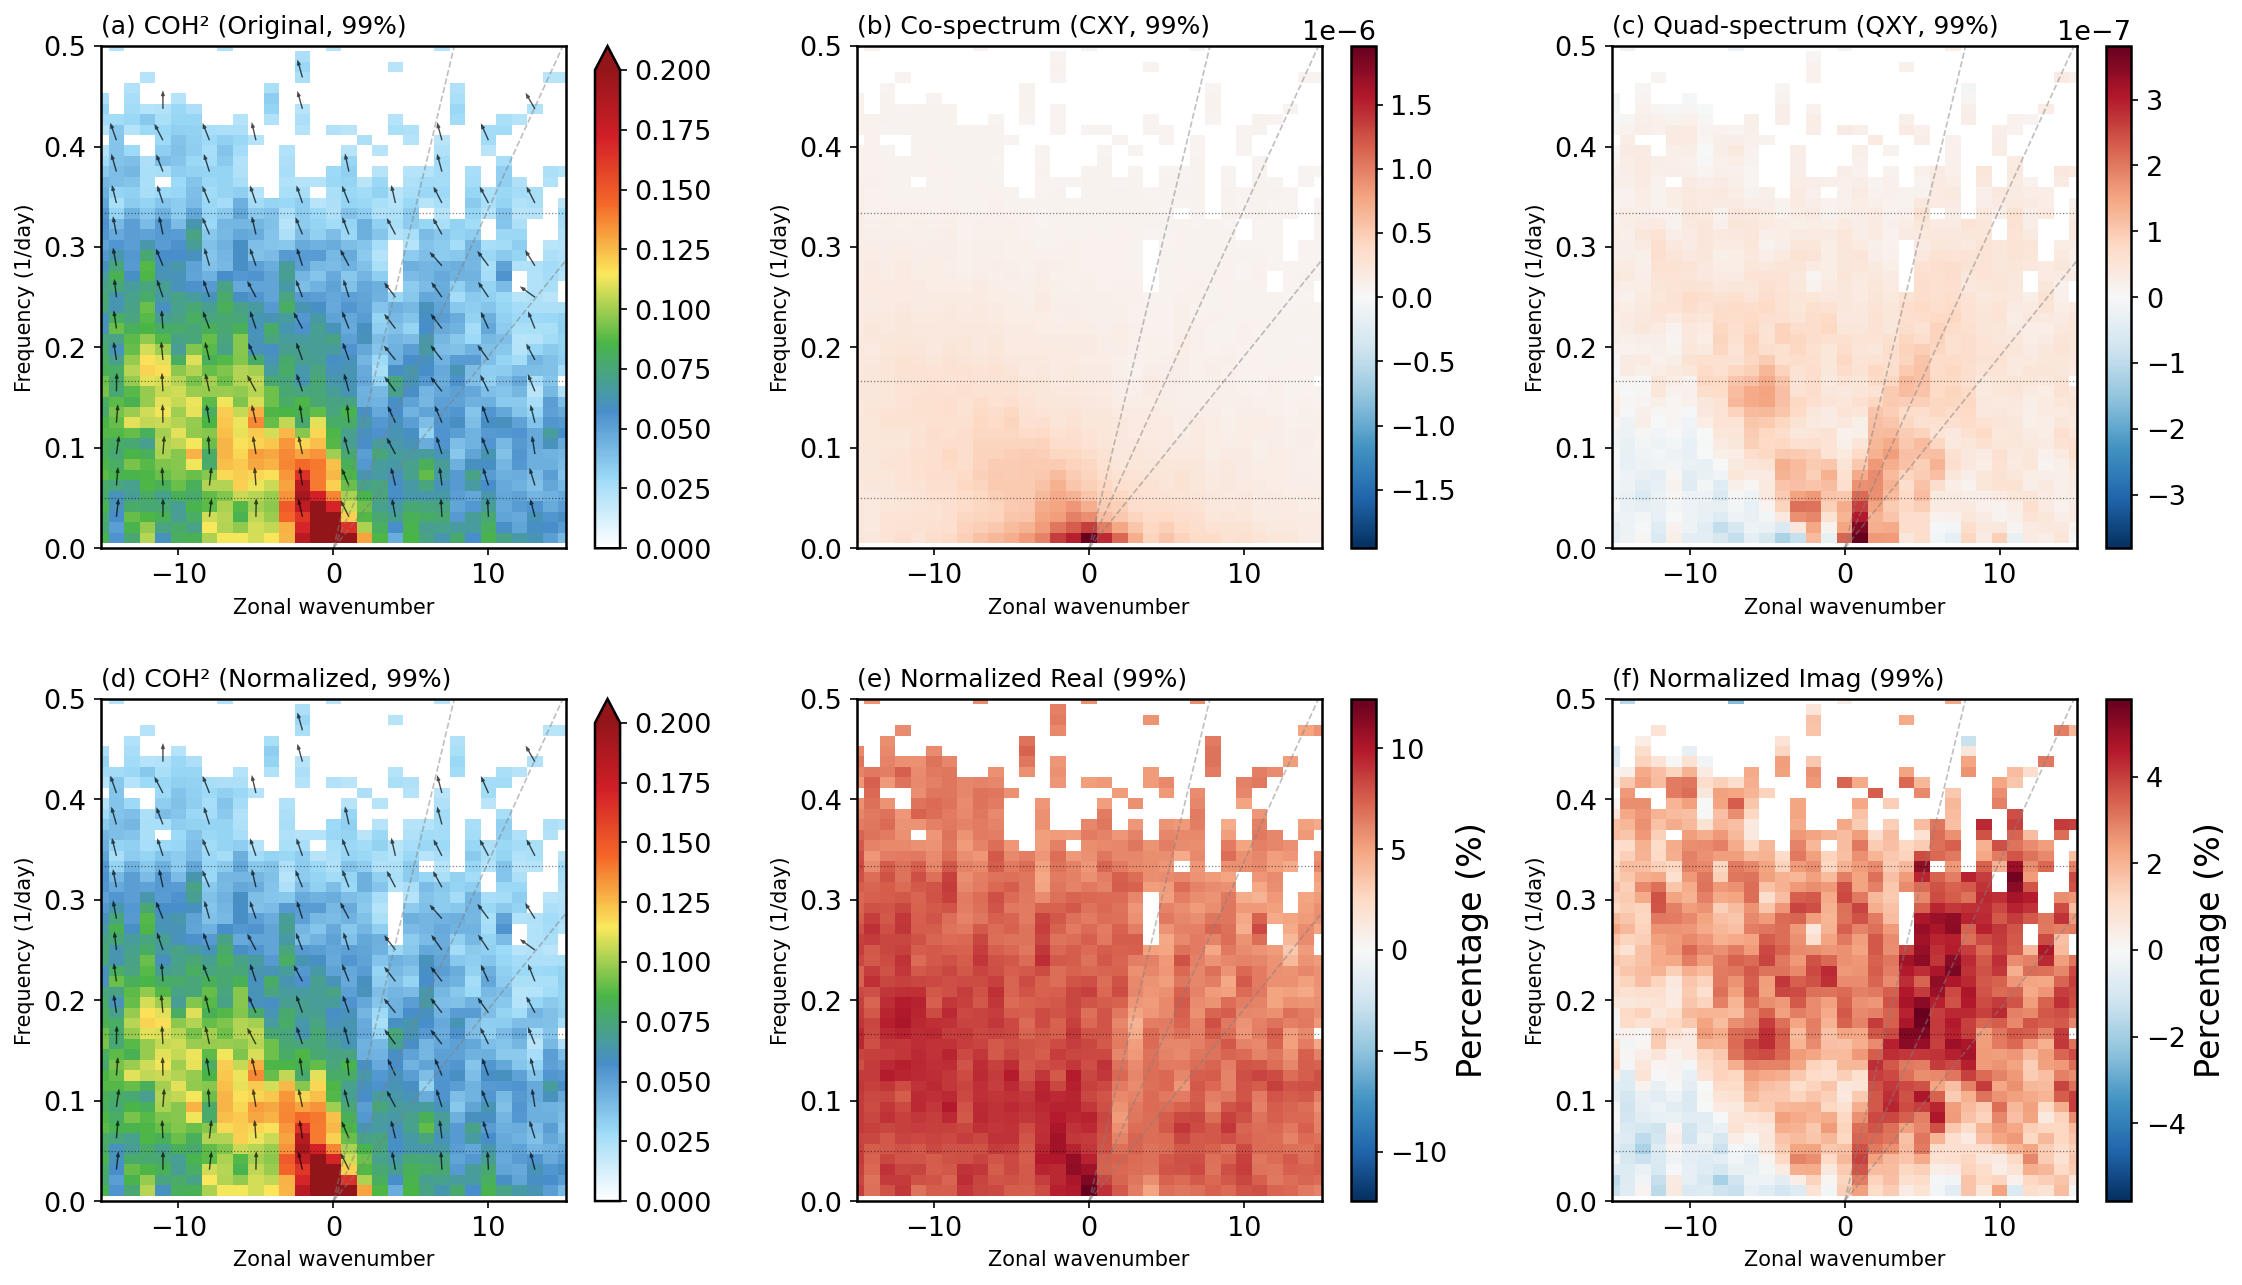

In [26]:
# ============ 可视化对比（带99%显著性检验和风场）============

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Kelvin波区域（用于对比）
kelvin_wave = slice(1, 10)
kelvin_freq = slice(0.03, 0.2)

# 🔑 获取99%置信水平的临界值
coh2_99_threshold_array = result_original['prob_coh2']
if isinstance(coh2_99_threshold_array, np.ndarray) and coh2_99_threshold_array.size > 1:
    coh2_99_threshold = float(coh2_99_threshold_array.max())
elif hasattr(coh2_99_threshold_array, 'item'):
    coh2_99_threshold = float(coh2_99_threshold_array.item())
else:
    coh2_99_threshold = float(coh2_99_threshold_array)

print(f"99%显著性阈值 = {coh2_99_threshold:.6f}")

# 获取频率和波数
zonalwnum = result_original['wave']
freq = result_original['freq']

# 第一行：原始方法（应用99%检验）
print("\n第一行：原始方法（99%显著性检验）")

# (a) COH2 - 原始方法
coh2_orig = result_original['STC'].sel(component='COH2')
coh2_orig_masked = coh2_orig.where(coh2_orig >= coh2_99_threshold)
n_sig = int((coh2_orig >= coh2_99_threshold).sum())
print(f"  COH2: {n_sig}/{coh2_orig.size} 点通过检验")

coh2_orig_masked.plot(
    ax=axes[0, 0], cmap=cmaps.WhiteBlueGreenYellowRed,
    vmin=0, vmax=0.2, add_colorbar=True, add_labels=False
)
axes[0, 0].set_title('(a) COH² (Original, 99%)', fontsize=12, loc='left')
axes[0, 0].set_xlim(-15, 15)
axes[0, 0].set_ylim(0, 0.5)

# 添加风场（原始方法）
skip = 3
wave_sub = zonalwnum[::skip]
freq_sub = freq[::skip]
u_sub = result_original['STC'].sel(component='V1').values[::skip, ::skip]
v_sub = result_original['STC'].sel(component='V2').values[::skip, ::skip]
coh2_sub = result_original['STC'].sel(component='COH2').values[::skip, ::skip]
mask = coh2_sub < coh2_99_threshold
u_masked = np.where(mask, np.nan, u_sub)
v_masked = np.where(mask, np.nan, v_sub)
if np.sum(~np.isnan(u_masked)) > 0:
    axes[0, 0].quiver(wave_sub, freq_sub, u_masked, v_masked,
                      scale=25, headwidth=3, headlength=4, width=0.003, alpha=0.7)

# (b) CXY - 原始方法（应用COH2掩蔽）
cxy_orig = result_original['STC'].sel(component='CXY')
cxy_orig_masked = cxy_orig.where(coh2_orig >= coh2_99_threshold)

cxy_orig_masked.plot(
    ax=axes[0, 1], cmap='RdBu_r', center=0, add_colorbar=True, add_labels=False
)
axes[0, 1].set_title('(b) Co-spectrum (CXY, 99%)', fontsize=12, loc='left')
axes[0, 1].set_xlim(-15, 15)
axes[0, 1].set_ylim(0, 0.5)

# (c) QXY - 原始方法（应用COH2掩蔽）
qxy_orig = result_original['STC'].sel(component='QXY')
qxy_orig_masked = qxy_orig.where(coh2_orig >= coh2_99_threshold)

qxy_orig_masked.plot(
    ax=axes[0, 2], cmap='RdBu_r', center=0, add_colorbar=True, add_labels=False
)
axes[0, 2].set_title('(c) Quad-spectrum (QXY, 99%)', fontsize=12, loc='left')
axes[0, 2].set_xlim(-15, 15)
axes[0, 2].set_ylim(0, 0.5)

# 第二行：标准化方法（应用99%检验）
print("\n第二行：标准化方法（99%显著性检验）")

# (d) COH2 - 标准化方法
coh2_norm = result_normalized['STC'].sel(component='COH2')
coh2_norm_masked = coh2_norm.where(coh2_norm >= coh2_99_threshold)
n_sig = int((coh2_norm >= coh2_99_threshold).sum())
print(f"  COH2: {n_sig}/{coh2_norm.size} 点通过检验")

coh2_norm_masked.plot(
    ax=axes[1, 0], cmap=cmaps.WhiteBlueGreenYellowRed,
    vmin=0, vmax=0.2, add_colorbar=True, add_labels=False
)
axes[1, 0].set_title('(d) COH² (Normalized, 99%)', fontsize=12, loc='left')
axes[1, 0].set_xlim(-15, 15)
axes[1, 0].set_ylim(0, 0.5)

# 添加风场（标准化方法）
u_sub_norm = result_normalized['STC'].sel(component='V1').values[::skip, ::skip]
v_sub_norm = result_normalized['STC'].sel(component='V2').values[::skip, ::skip]
coh2_sub_norm = result_normalized['STC'].sel(component='COH2').values[::skip, ::skip]
mask_norm = coh2_sub_norm < coh2_99_threshold
u_masked_norm = np.where(mask_norm, np.nan, u_sub_norm)
v_masked_norm = np.where(mask_norm, np.nan, v_sub_norm)
if np.sum(~np.isnan(u_masked_norm)) > 0:
    axes[1, 0].quiver(wave_sub, freq_sub, u_masked_norm, v_masked_norm,
                      scale=25, headwidth=3, headlength=4, width=0.003, alpha=0.7)

# (e) NORM_CXY_REAL - 标准化实部（应用COH2掩蔽）
norm_real = result_normalized['STC'].sel(component='NORM_CXY_REAL')
norm_real_masked = norm_real.where(coh2_norm >= coh2_99_threshold)

(norm_real_masked * 100).plot(
    ax=axes[1, 1], cmap='RdBu_r', center=0, add_colorbar=True,
    cbar_kwargs={'label': 'Percentage (%)'}, add_labels=False
)
axes[1, 1].set_title('(e) Normalized Real (99%)', fontsize=12, loc='left')
axes[1, 1].set_xlim(-15, 15)
axes[1, 1].set_ylim(0, 0.5)

# (f) NORM_CXY_IMAG - 标准化虚部（应用COH2掩蔽）
norm_imag = result_normalized['STC'].sel(component='NORM_CXY_IMAG')
norm_imag_masked = norm_imag.where(coh2_norm >= coh2_99_threshold)

(norm_imag_masked * 100).plot(
    ax=axes[1, 2], cmap='RdBu_r', center=0, add_colorbar=True,
    cbar_kwargs={'label': 'Percentage (%)'}, add_labels=False
)
axes[1, 2].set_title('(f) Normalized Imag (99%)', fontsize=12, loc='left')
axes[1, 2].set_xlim(-15, 15)
axes[1, 2].set_ylim(0, 0.5)

# 为所有子图添加参考线
for ax in axes.flatten():
    # Kelvin波色散关系
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / 86400 / cp * 2 * np.pi * 6371000
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=0.8, 
                linestyle='dashed', alpha=0.5)
    
    # 周期线
    for period in [3, 6, 20]:
        ax.axhline(1/period, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Zonal wavenumber', fontsize=10)
    ax.set_ylabel('Frequency (1/day)', fontsize=10)

plt.savefig(FIG_SAVE_DIR + 'comparison_normalized_vs_original.png', 
            bbox_inches='tight', dpi=150)
print(f"✅ 对比图已保存到: {FIG_SAVE_DIR}comparison_normalized_vs_original.png")
plt.show()